In [1]:

# EXPLORATORY DATA ANALYSIS
# Objective: Understand customer behavior patterns
# Concepts: Descriptive statistics, KDE, Correlation, PCA

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import warnings

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

df = pd.read_csv('../data/online_retail_cleaned.csv')
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

print(f"Dataset shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
df.head()


Dataset shape: (324716, 9)
Columns: ['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country', 'TotalAmount']


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalAmount
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34


In [2]:

# DESCRIPTIVE STATISTICS

print("\nNumerical columns summary:")
print(df[['Quantity', 'UnitPrice', 'TotalAmount']].describe())

print("\nAdditional statistics:")
for col in ['Quantity', 'UnitPrice', 'TotalAmount']:
    print(f"\n{col}:")
    print(f"  Skewness: {df[col].skew():.3f}")
    print(f"  Kurtosis: {df[col].kurtosis():.3f}")


Numerical columns summary:
            Quantity      UnitPrice    TotalAmount
count  324716.000000  324716.000000  324716.000000
mean        7.070970       2.123759      10.854211
std         6.486069       1.500057       8.235695
min         1.000000       0.001000       0.001000
25%         2.000000       0.950000       3.750000
50%         5.000000       1.650000       9.900000
75%        12.000000       2.950000      16.500000
max        27.000000       7.500000      37.700000

Additional statistics:

Quantity:
  Skewness: 1.312
  Kurtosis: 1.089

UnitPrice:
  Skewness: 1.122
  Kurtosis: 0.713

TotalAmount:
  Skewness: 0.807
  Kurtosis: 0.090


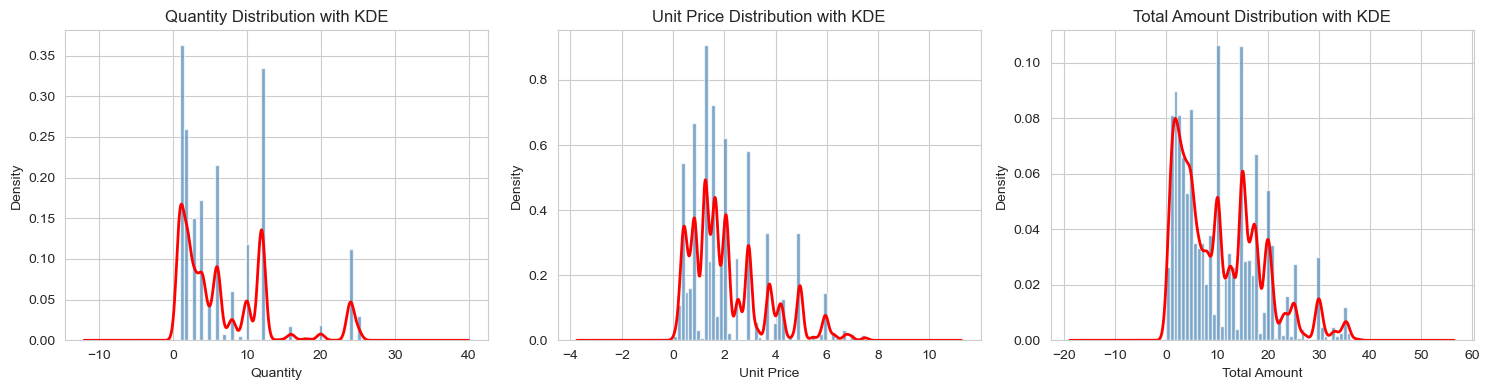

KDE (Kernel Density Estimation) is a non-parametric method
that estimates probability density without assuming a distribution.


In [3]:

# DISTRIBUTION ANALYSIS WITH KDE
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Quantity distribution
axes[0].hist(df['Quantity'], bins=50, density=True, alpha=0.7, color='steelblue')
df['Quantity'].plot.kde(ax=axes[0], color='red', linewidth=2)
axes[0].set_title('Quantity Distribution with KDE')
axes[0].set_xlabel('Quantity')

# UnitPrice distribution
axes[1].hist(df['UnitPrice'], bins=50, density=True, alpha=0.7, color='steelblue')
df['UnitPrice'].plot.kde(ax=axes[1], color='red', linewidth=2)
axes[1].set_title('Unit Price Distribution with KDE')
axes[1].set_xlabel('Unit Price')

# TotalAmount distribution
axes[2].hist(df['TotalAmount'], bins=50, density=True, alpha=0.7, color='steelblue')
df['TotalAmount'].plot.kde(ax=axes[2], color='red', linewidth=2)
axes[2].set_title('Total Amount Distribution with KDE')
axes[2].set_xlabel('Total Amount')

plt.tight_layout()
plt.savefig('../outputs/figures/distributions_kde.png', dpi=150, bbox_inches='tight')
plt.show()

print("KDE (Kernel Density Estimation) is a non-parametric method")
print("that estimates probability density without assuming a distribution.")


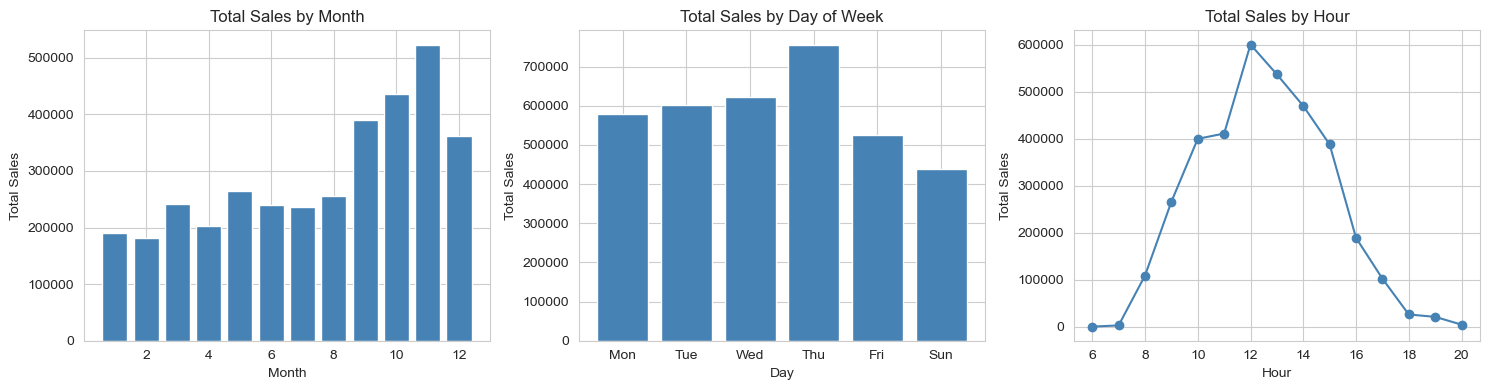

In [4]:

# TIME-BASED PATTERNS

df['Month'] = df['InvoiceDate'].dt.month
df['DayOfWeek'] = df['InvoiceDate'].dt.dayofweek
df['Hour'] = df['InvoiceDate'].dt.hour

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Monthly sales
monthly = df.groupby('Month')['TotalAmount'].sum()
axes[0].bar(monthly.index, monthly.values, color='steelblue')
axes[0].set_title('Total Sales by Month')
axes[0].set_xlabel('Month')
axes[0].set_ylabel('Total Sales')

# Day of week
days = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
daily = df.groupby('DayOfWeek')['TotalAmount'].sum()
axes[1].bar([days[i] for i in daily.index], daily.values, color='steelblue')
axes[1].set_title('Total Sales by Day of Week')
axes[1].set_xlabel('Day')
axes[1].set_ylabel('Total Sales')

# Hourly
hourly = df.groupby('Hour')['TotalAmount'].sum()
axes[2].plot(hourly.index, hourly.values, marker='o', color='steelblue')
axes[2].set_title('Total Sales by Hour')
axes[2].set_xlabel('Hour')
axes[2].set_ylabel('Total Sales')

plt.tight_layout()
plt.savefig('../outputs/figures/time_patterns.png', dpi=150, bbox_inches='tight')
plt.show()


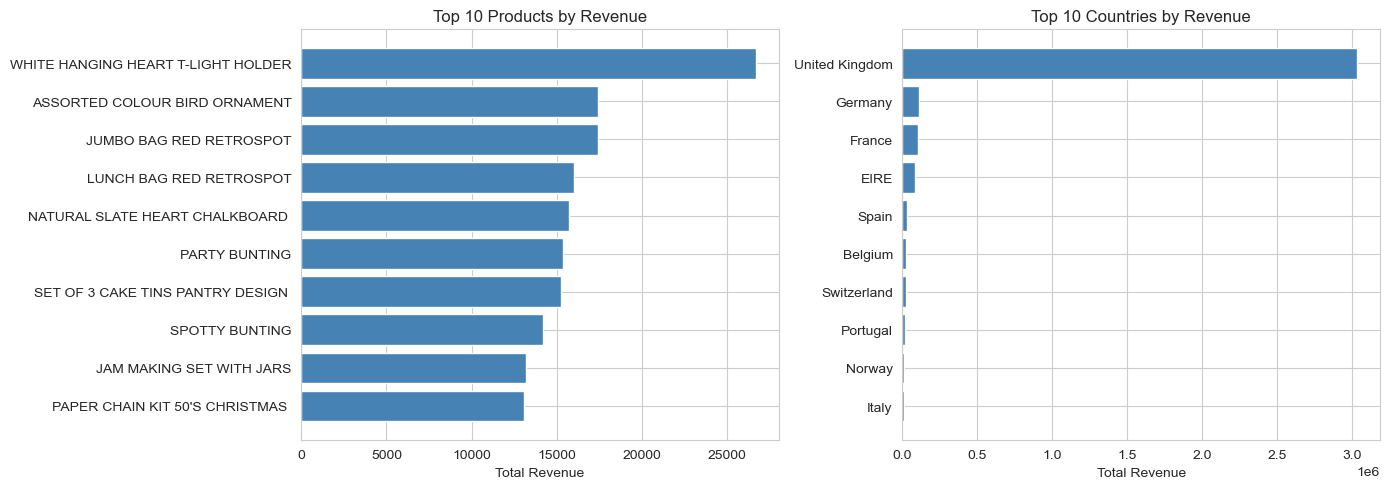

In [5]:

# TOP PRODUCTS AND COUNTRIES

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Top 10 products by revenue
top_products = df.groupby('Description')['TotalAmount'].sum().nlargest(10)
axes[0].barh(top_products.index, top_products.values, color='steelblue')
axes[0].set_title('Top 10 Products by Revenue')
axes[0].set_xlabel('Total Revenue')
axes[0].invert_yaxis()

# Top 10 countries by revenue
top_countries = df.groupby('Country')['TotalAmount'].sum().nlargest(10)
axes[1].barh(top_countries.index, top_countries.values, color='steelblue')
axes[1].set_title('Top 10 Countries by Revenue')
axes[1].set_xlabel('Total Revenue')
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig('../outputs/figures/top_products_countries.png', dpi=150, bbox_inches='tight')
plt.show()


In [6]:

#CREATE CUSTOMER LEVEL DATA

reference_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

customer_df = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (reference_date - x.max()).days,  # Recency
    'InvoiceNo': 'nunique',  # Frequency
    'TotalAmount': 'sum',  # Monetary
    'Quantity': 'sum',  # Total items
    'StockCode': 'nunique'  # Unique products
}).reset_index()

customer_df.columns = ['CustomerID', 'Recency', 'Frequency', 'Monetary', 'TotalItems', 'UniqueProducts']

# Add average order value
customer_df['AvgOrderValue'] = customer_df['Monetary'] / customer_df['Frequency']

print(f"Customer dataset shape: {customer_df.shape}")
print(f"\nCustomer features summary:")
print(customer_df.describe())

Customer dataset shape: (4146, 7)

Customer features summary:
         CustomerID      Recency    Frequency      Monetary    TotalItems  \
count   4146.000000  4146.000000  4146.000000   4146.000000   4146.000000   
mean   15296.229378    93.181380     3.918234    850.105138    553.800531   
std     1718.519565   100.015984     6.813902   1767.635549   1144.629218   
min    12347.000000     1.000000     1.000000      1.700000      1.000000   
25%    13819.500000    18.000000     1.000000    173.970000    104.000000   
50%    15290.500000    51.000000     2.000000    405.625000    262.000000   
75%    16775.750000   145.000000     4.000000    964.527500    639.750000   
max    18287.000000   374.000000   193.000000  70409.910000  45058.000000   

       UniqueProducts  AvgOrderValue  
count     4146.000000    4146.000000  
mean        54.427159     218.406817  
std         75.814602     184.412698  
min          1.000000       1.700000  
25%         13.000000     107.318750  
50%       

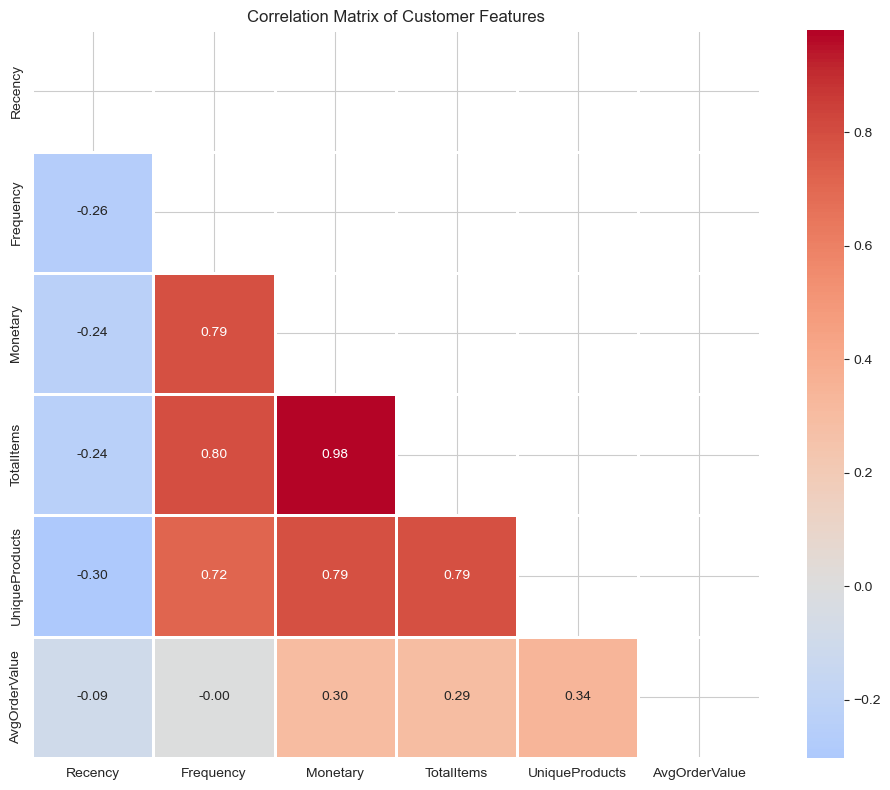


Key correlations:
  Frequency vs Monetary: 0.793
  Frequency vs UniqueProducts: 0.717
  Recency vs Frequency: -0.261


In [7]:

# CORRELATION ANALYSIS
features = ['Recency', 'Frequency', 'Monetary', 'TotalItems', 'UniqueProducts', 'AvgOrderValue']
corr_matrix = customer_df[features].corr()

plt.figure(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=1)
plt.title('Correlation Matrix of Customer Features')
plt.tight_layout()
plt.savefig('../outputs/figures/correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nKey correlations:")
print(f"  Frequency vs Monetary: {corr_matrix.loc['Frequency', 'Monetary']:.3f}")
print(f"  Frequency vs UniqueProducts: {corr_matrix.loc['Frequency', 'UniqueProducts']:.3f}")
print(f"  Recency vs Frequency: {corr_matrix.loc['Recency', 'Frequency']:.3f}")


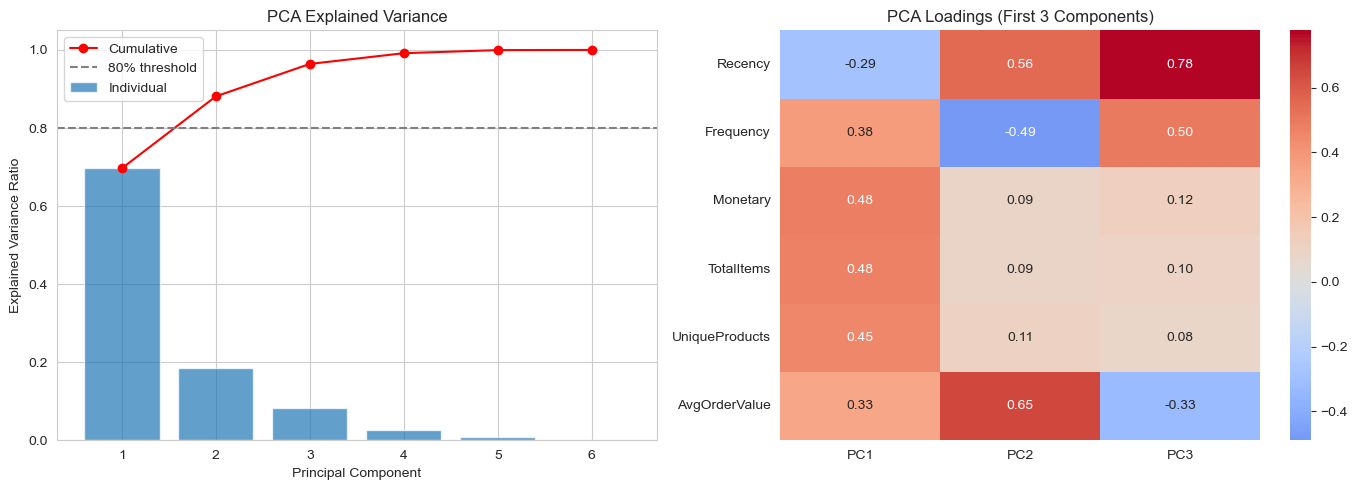


Explained variance by component:
  PC1: 0.697 (0.697 cumulative)
  PC2: 0.184 (0.881 cumulative)
  PC3: 0.083 (0.964 cumulative)
  PC4: 0.027 (0.992 cumulative)
  PC5: 0.008 (1.000 cumulative)
  PC6: 0.000 (1.000 cumulative)

PC1 and PC2 explain 88.1% of variance


In [8]:

# PCA FOR DIMENSIONALITY REDUCTION
X = customer_df[features].copy()
X_log = np.log1p(X)  # Log transform to handle skewness
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_log)

# Apply PCA
pca = PCA()
pca_result = pca.fit_transform(X_scaled)

# Explained variance
explained_var = pca.explained_variance_ratio_
cumulative_var = np.cumsum(explained_var)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scree plot
axes[0].bar(range(1, len(explained_var) + 1), explained_var, alpha=0.7, label='Individual')
axes[0].plot(range(1, len(explained_var) + 1), cumulative_var, 'ro-', label='Cumulative')
axes[0].axhline(y=0.8, color='gray', linestyle='--', label='80% threshold')
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Explained Variance Ratio')
axes[0].set_title('PCA Explained Variance')
axes[0].legend()
axes[0].set_xticks(range(1, len(explained_var) + 1))

# PCA loadings
loadings = pd.DataFrame(
    pca.components_.T,
    columns=[f'PC{i+1}' for i in range(len(features))],
    index=features
)
sns.heatmap(loadings[['PC1', 'PC2', 'PC3']], annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=axes[1])
axes[1].set_title('PCA Loadings (First 3 Components)')

plt.tight_layout()
plt.savefig('../outputs/figures/pca_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nExplained variance by component:")
for i, var in enumerate(explained_var):
    print(f"  PC{i+1}: {var:.3f} ({cumulative_var[i]:.3f} cumulative)")

print(f"\nPC1 and PC2 explain {cumulative_var[1]*100:.1f}% of variance")



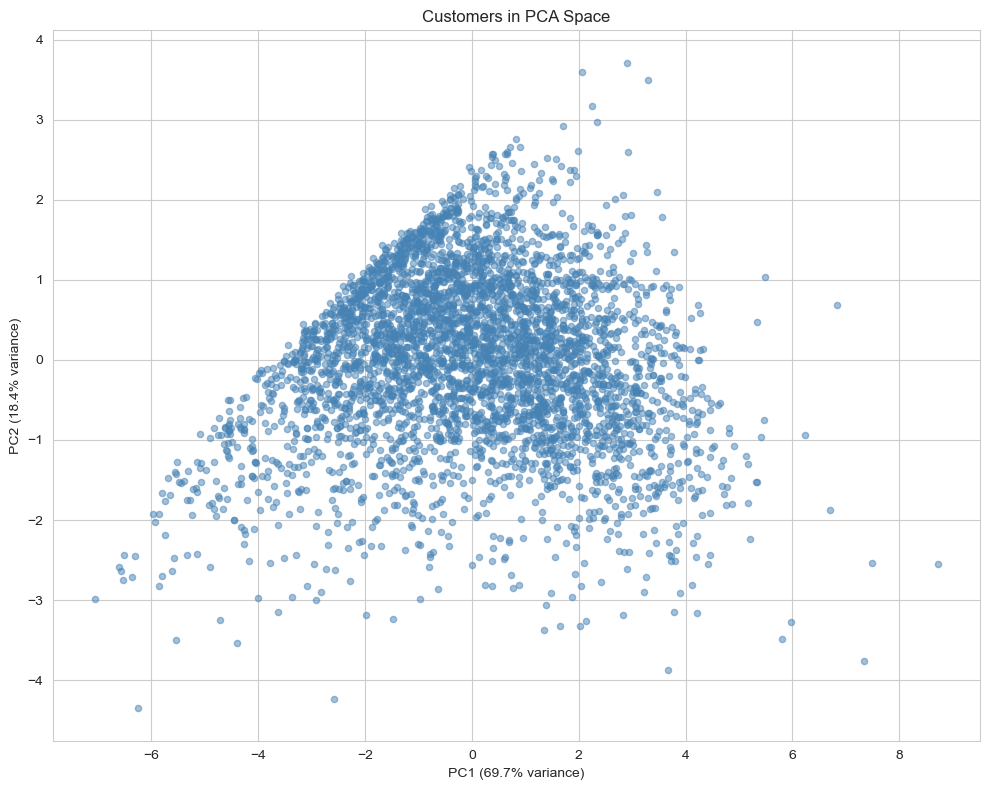

In [9]:

# VISUALIZE CUSTOMERS IN PCA SPACE
customer_df['PC1'] = pca_result[:, 0]
customer_df['PC2'] = pca_result[:, 1]

plt.figure(figsize=(10, 8))
plt.scatter(customer_df['PC1'], customer_df['PC2'], alpha=0.5, c='steelblue', s=20)
plt.xlabel(f'PC1 ({explained_var[0]*100:.1f}% variance)')
plt.ylabel(f'PC2 ({explained_var[1]*100:.1f}% variance)')
plt.title('Customers in PCA Space')
plt.tight_layout()
plt.savefig('../outputs/figures/customers_pca_space.png', dpi=150, bbox_inches='tight')
plt.show()


In [10]:

#  SAVE CUSTOMER DATA
customer_df.to_csv('../data/customer_features.csv', index=False)
print("Customer features saved to '../data/customer_features.csv'")

Customer features saved to '../data/customer_features.csv'



Key findings:
1. Sales data is right skewed (KDE analysis)
2. Strong correlation between Frequency and Monetary
3. First 2 PCA components capture majority of variance
4. Customer base shows natural variation in PCA space